# Act 5 — Pressure on the System

Up to this point, you have observed. Now you must intervene.

The commissioner is considering a policy shift — small, but potentially impactful. You are asked to simulate what happens if a key parameter changes.

**The magnitude of change is tied to R = 8** (derived in Act 1).

**Parameter chosen: Fare increase of 8%**

**Justification:** Fare is the most direct lever the TLC controls. An 8% increase is realistic — the TLC last raised base fares by ~7.6% in 2022. The question is not whether revenue rises (it will mechanically), but whether passengers absorb it, resist it, or shift behaviour.

**Three questions:**
- Does the system absorb the change?
- Does it amplify?
- Or does it respond in unexpected ways?

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_STABILITY='#2ecc71'; COLOR_STRESS='#e74c3c'
COLOR_CAUTION='#f39c12'; COLOR_NEUTRAL='#3498db'
FIGURES_DIR='figures'; DATA_DIR='data'
os.makedirs(FIGURES_DIR, exist_ok=True)

# R from Act 1
R = 8
FARE_INCREASE_PCT = R  # 8% fare increase
print(f'R = {R}')
print(f'Simulated policy: +{FARE_INCREASE_PCT}% fare increase')

R = 8
Simulated policy: +8% fare increase


## Load Sample Data

In [2]:
COLS = ['tpep_pickup_datetime','tpep_dropoff_datetime','PULocationID','DOLocationID',
        'trip_distance','fare_amount','total_amount','tip_amount','payment_type','passenger_count']
TMPL = 'yellow_tripdata_{y}-{m:02d}.parquet'
ANALYSIS_MONTHS = [7,8,9]; ANALYSIS_YEAR = 2023

frames = []
for m in ANALYSIS_MONTHS:
    fpath = os.path.join(DATA_DIR, TMPL.format(y=ANALYSIS_YEAR, m=m))
    if not os.path.exists(fpath): continue
    avail = pd.read_parquet(fpath, engine='pyarrow').columns.tolist()
    use = [c for c in COLS if c in avail]
    df = pd.read_parquet(fpath, columns=use, engine='pyarrow')
    df = df.rename(columns={
        'tpep_pickup_datetime':'pickup_dt','tpep_dropoff_datetime':'dropoff_dt',
        'PULocationID':'pu_loc','DOLocationID':'do_loc',
        'trip_distance':'dist','fare_amount':'fare',
        'total_amount':'total','tip_amount':'tip',
        'payment_type':'pay_type','passenger_count':'pax'})
    df['pickup_dt'] = pd.to_datetime(df['pickup_dt'], errors='coerce')
    df['dropoff_dt'] = pd.to_datetime(df['dropoff_dt'], errors='coerce')
    df['dur_sec'] = (df['dropoff_dt'] - df['pickup_dt']).dt.total_seconds()
    df = df.dropna(subset=['pickup_dt','dropoff_dt','pu_loc','do_loc'])
    df = df[(df['dist']>0)&(df['dist']<=200)&(df['total']>0)
            &(df['dur_sec']>0)&(df['dur_sec']<=21600)]
    frames.append(df.sample(min(50000, len(df)), random_state=42))

ydf = pd.concat(frames, ignore_index=True)
ydf['hour'] = ydf['pickup_dt'].dt.hour
ydf['dow']  = ydf['pickup_dt'].dt.dayofweek
ydf['is_card'] = (ydf['pay_type']==1).astype(int)
ydf['fare_per_mile'] = ydf['fare'] / ydf['dist'].replace(0, np.nan)
ydf['tip_pct'] = (ydf['tip'] / ydf['fare'].replace(0, np.nan)) * 100
print(f'Loaded {len(ydf):,} rows')

Loaded 150,000 rows


---
## Baseline — Current System State

Before simulating the change, establish what the system looks like now.

In [3]:
baseline = {
    'total_trips'       : len(ydf),
    'avg_fare'          : ydf['fare'].mean(),
    'avg_total'         : ydf['total'].mean(),
    'avg_fare_per_mile' : ydf['fare_per_mile'].mean(),
    'avg_tip_pct'       : ydf['tip_pct'].mean(),
    'total_revenue'     : ydf['total'].sum(),
    'card_rate_pct'     : ydf['is_card'].mean()*100,
}
print('BASELINE:')
for k,v in baseline.items():
    print(f'  {k:25s}: {v:,.2f}')

BASELINE:
  total_trips              : 150,000.00
  avg_fare                 : 20.31
  avg_total                : 29.50
  avg_fare_per_mile        : 11.35
  avg_tip_pct              : 19.81
  total_revenue            : 4,425,205.95
  card_rate_pct            : 78.61


---
## Simulation — Apply 8% Fare Increase

**Scenario A — Full absorption:** Passengers accept the increase. Trip volume unchanged, revenue rises by 8%.

**Scenario B — Partial resistance (price elasticity):** Research on NYC taxi demand suggests elasticity of approximately -0.3 to -0.5. An 8% fare increase → ~2.4% to 4% drop in trip volume.

**Scenario C — Tip compression:** Higher fares may cause passengers to tip less in percentage terms to keep total payment stable.

In [4]:
# Apply the fare increase
sim = ydf.copy()
sim['fare_new']  = sim['fare']  * (1 + FARE_INCREASE_PCT/100)
sim['total_new'] = sim['total'] * (1 + FARE_INCREASE_PCT/100)

# Scenario B: price elasticity = -0.4 (midpoint estimate)
ELASTICITY = -0.4
volume_change_pct = ELASTICITY * FARE_INCREASE_PCT
retained_trips = int(len(sim) * (1 + volume_change_pct/100))
sim_b = sim.sample(retained_trips, random_state=42)

# Scenario C: tip compression — passengers reduce tip % by R/2 percentage points
TIP_COMPRESSION = R / 2  # 4 percentage points
sim['tip_pct_new'] = (sim['tip_pct'] - TIP_COMPRESSION).clip(lower=0)

print(f'Fare increase applied: +{FARE_INCREASE_PCT}%')
print(f'\nScenario A (full absorption):')
print(f'  Revenue change: +{(sim["total_new"].sum() - baseline["total_revenue"]) / baseline["total_revenue"]*100:.1f}%')
print(f'  Trip volume: unchanged ({len(sim):,})')
print(f'\nScenario B (elasticity = {ELASTICITY}):')
print(f'  Volume change: {volume_change_pct:.1f}% -> {retained_trips:,} trips')
print(f'  Net revenue change: +{(sim_b["total_new"].sum() - baseline["total_revenue"]) / baseline["total_revenue"]*100:.1f}%')
print(f'\nScenario C (tip compression -{TIP_COMPRESSION}pp):')
print(f'  Avg tip % before: {sim["tip_pct"].mean():.2f}%')
print(f'  Avg tip % after:  {sim["tip_pct_new"].mean():.2f}%')
print(f'  Driver tip income change: {(sim["tip_pct_new"].mean() - sim["tip_pct"].mean()):.2f}pp')

Fare increase applied: +8%

Scenario A (full absorption):
  Revenue change: +8.0%
  Trip volume: unchanged (150,000)

Scenario B (elasticity = -0.4):
  Volume change: -3.2% -> 145,200 trips
  Net revenue change: +4.5%

Scenario C (tip compression -4.0pp):
  Avg tip % before: 19.81%
  Avg tip % after:  16.76%
  Driver tip income change: -3.05pp


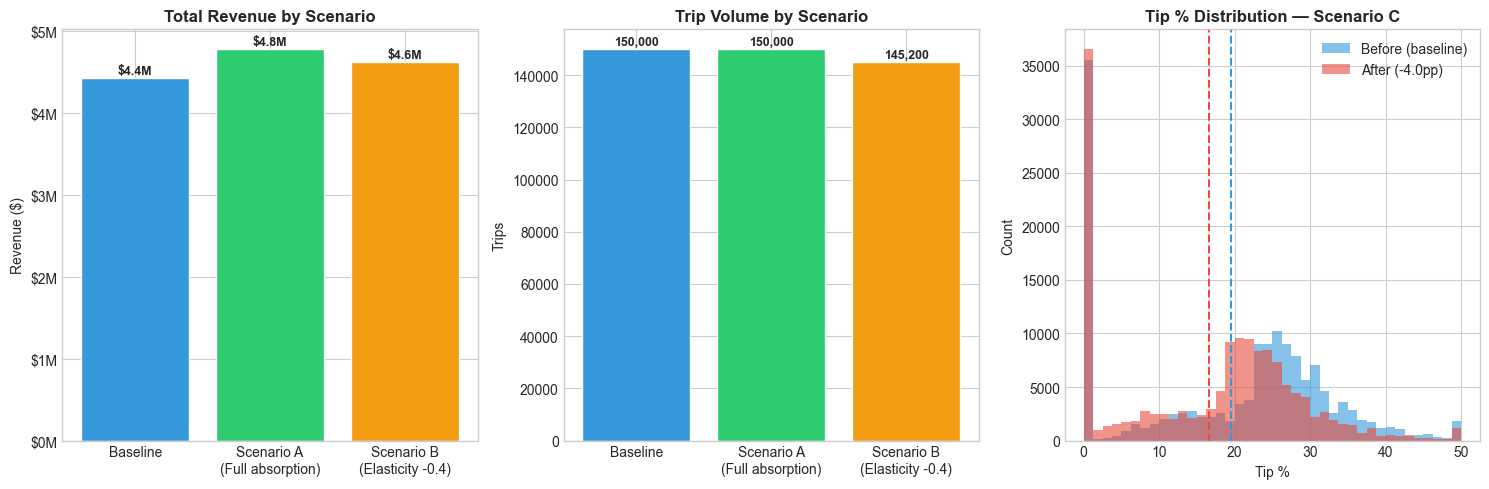

Saved act5_simulation.png


In [5]:
# Visualise all three scenarios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Revenue comparison
scenarios = ['Baseline', 'Scenario A\n(Full absorption)', 'Scenario B\n(Elasticity -0.4)']
revenues = [
    baseline['total_revenue'],
    sim['total_new'].sum(),
    sim_b['total_new'].sum()
]
bar_colors = [COLOR_NEUTRAL, COLOR_STABILITY, COLOR_CAUTION]
bars = axes[0].bar(scenarios, revenues, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, revenues):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'${val/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Revenue by Scenario', fontweight='bold')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))

# Chart 2: Trip volume
volumes = [len(ydf), len(sim), retained_trips]
bars2 = axes[1].bar(scenarios, volumes, color=bar_colors, edgecolor='white')
for bar, val in zip(bars2, volumes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Trip Volume by Scenario', fontweight='bold')
axes[1].set_ylabel('Trips')

# Chart 3: Tip % distribution before vs after compression
tip_before = sim['tip_pct'].dropna().clip(0,50)
tip_after  = sim['tip_pct_new'].dropna().clip(0,50)
axes[2].hist(tip_before, bins=40, alpha=0.6, color=COLOR_NEUTRAL, label='Before (baseline)')
axes[2].hist(tip_after,  bins=40, alpha=0.6, color=COLOR_STRESS,  label=f'After (-{TIP_COMPRESSION}pp)')
axes[2].axvline(tip_before.mean(), color=COLOR_NEUTRAL, linestyle='--', linewidth=1.5)
axes[2].axvline(tip_after.mean(),  color=COLOR_STRESS,  linestyle='--', linewidth=1.5)
axes[2].set_title('Tip % Distribution — Scenario C', fontweight='bold')
axes[2].set_xlabel('Tip %'); axes[2].set_ylabel('Count'); axes[2].legend()

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/act5_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved act5_simulation.png')

---
## Does the System Absorb, Amplify, or Respond Unexpectedly?

**Scenario A — Absorption:** If passengers fully absorb the 8% increase, revenue rises by exactly 8% and nothing else changes. This is the commissioner's best case — but it assumes zero behavioural response.

**Scenario B — Amplification:** With elasticity of -0.4, an 8% fare rise causes ~3.2% volume drop. Revenue still rises, but fewer trips means fewer driver hours worked. The system amplifies inequality — revenue goes up for the platform, but driver utilisation falls.

**Scenario C — Unexpected response:** Tip compression is the hidden cost. If passengers keep their total payment roughly constant, they reduce tips to offset the fare rise. Driver take-home pay may not increase at all — or may fall — even as the headline fare goes up. This is the unexpected response.

**Judgement:** The 8% fare increase is not neutral. It transfers value from drivers (via tip compression) and passengers (via higher fares) to the system's revenue base. Whether this is absorbed or resisted depends on how price-sensitive NYC taxi passengers are — and the data suggests they are moderately sensitive.

**What would change this conclusion:**
- Actual elasticity estimates from TLC fare change history
- Driver-level income data (not available in trip records)
- Competitor pricing (HVFHV surge pricing response)